<a href="https://colab.research.google.com/github/francorte/data-analysis-lab/blob/main/notebooks/02_tratamiento_valores_faltantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tratamiento de valores faltantes

En este notebook vamos a explorar qué podemos hacer cuando nos encontramos con valores faltantes en un dataset.

Los valores faltantes aparecen cuando una variable no tiene información registrada para una o varias observaciones. Esto puede ocurrir por errores en la recogida de datos, respuestas incompletas, fallos de carga, ausencia real de información o decisiones del propio proceso de medición.

En análisis de datos es importante identificar y tratar estos valores porque pueden afectar a los resultados estadísticos, distorsionar conclusiones y provocar errores en modelos de Machine Learning. Muchos algoritmos, especialmente los implementados en `scikit-learn`, no aceptan datos incompletos como entrada.

En Python, `pandas` representa habitualmente los valores faltantes como `NaN` (*Not a Number*) y ofrece herramientas para identificarlos, contarlos, eliminarlos o reemplazarlos.

En este notebook veremos:

- Qué se entiende por valor faltante.
- Cómo detectar valores faltantes en `pandas`.
- Exploración inicial de los datos.
- Eliminación de observaciones con valores faltantes.
- Imputación con media o mediana.
- Imputación con moda o categoría más frecuente.
- Imputación con una observación aleatoria.
- Sustitución por un número arbitrario.
- Sustitución por valores al final de la distribución.
- Captura de información contenida en los valores faltantes.
- Tratamiento de valores faltantes con `scikit-learn`.
- Creación de una canalización con `Pipeline` y `ColumnTransformer`.

El objetivo no es aplicar una técnica de forma automática, sino entender cuándo puede tener sentido cada estrategia y qué riesgos implica.

## Dataset utilizado

Vamos a utilizar el dataset **Credit Approval Dataset** de Kaggle.

Este dataset contiene información relacionada con operaciones de crédito. Los nombres de las características y algunos valores están anonimizados con símbolos o códigos arbitrarios para proteger la confidencialidad.

La variable objetivo será `A16`, y el resto de columnas se utilizarán como variables explicativas.

## 1. Descarga del dataset desde Kaggle

Para descargar datasets desde Kaggle en Google Colab necesitas configurar previamente tu token de API.

No guardes ni subas a GitHub ningún token real de Kaggle. En este notebook se deja solo una plantilla segura.

In [1]:
import os

# Plantilla segura.
# Ejecuta esta línea solo en tu sesión privada de Colab y no guardes el token real en GitHub.
# os.environ["KAGGLE_API_TOKEN"] = "PEGA_AQUI_TU_TOKEN_NUEVO"

In [2]:
!pip install -q --upgrade kaggle
!kaggle datasets download -d martaarroyo/credit-approval-dataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 7.4 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/martaarroyo/credit-approval-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 8.87k/8.87k [00:00<00:00, 14.9MB/s]



## 2. Importación de librerías

Importamos las librerías necesarias para el análisis, la visualización, la división entrenamiento/prueba y las estrategias de imputación.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

## 3. Descompresión y carga de datos

Descomprimimos el archivo descargado desde Kaggle y cargamos el archivo CSV en un DataFrame de `pandas`.

In [4]:
zip_path = "credit-approval-dataset.zip"
extract_path = "credit_approval_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Archivos descomprimidos:")
print(os.listdir(extract_path))

Archivos descomprimidos:
['CreditApproval.csv']


In [5]:
csv_files = [file for file in os.listdir(extract_path) if file.endswith(".csv")]
csv_files

['CreditApproval.csv']

In [6]:
file_path = os.path.join(extract_path, csv_files[0])
data = pd.read_csv(file_path)

data.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,1


## 4. Exploración inicial de los datos

Antes de tratar valores faltantes, revisamos la estructura general del dataset: dimensiones, columnas, tipos de datos y resumen estadístico.

In [7]:
print("Dimensiones del dataset:", data.shape)
print("\nColumnas:")
print(data.columns.tolist())

Dimensiones del dataset: (690, 16)

Columnas:
['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16']


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      600 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      600 non-null    float64
 8   A9      600 non-null    object 
 9   A10     600 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    int64  
dtypes: float64(4), int64(3), object(9)
memory usage: 86.4+ KB


In [9]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
A1,678,2,b,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A2,678.0,NaN,NaN,NaN,31.568171,11.957862,13.75,22.6025,28.46,38.23,80.25
A3,600.0,NaN,NaN,NaN,4.755758,4.840533,0.0,1.04,3.0,7.185,26.335
A4,684,3,u,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A5,684,3,g,519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A6,681,14,c,137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A7,681,9,v,399,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A8,600.0,NaN,NaN,NaN,2.146658,3.096899,0.0,0.165,1.0,2.595,20.0
A9,600,2,t,310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A10,600,2,f,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.1. Comprobaciones básicas de calidad

Antes de analizar los valores faltantes, comprobamos duplicados y posibles códigos de ausencia almacenados como texto. Esta revisión evita confundir símbolos como `?`, `NA` o cadenas vacías con valores válidos.


In [10]:
print("Filas duplicadas:", data.duplicated().sum())

codigos_ausencia = {"", "?", "NA", "N/A", "NULL", "null", "None", "-", "--"}

hallazgos_codigos = {}
for columna in data.select_dtypes(include="object").columns:
    valores_normalizados = data[columna].astype("string").str.strip()
    conteos = valores_normalizados[
        valores_normalizados.isin(codigos_ausencia)
    ].value_counts(dropna=False)

    if not conteos.empty:
        hallazgos_codigos[columna] = conteos.to_dict()

print("Posibles códigos de ausencia almacenados como texto:")
print(hallazgos_codigos if hallazgos_codigos else "No se detectaron.")


Filas duplicadas: 0
Posibles códigos de ausencia almacenados como texto:
No se detectaron.


## 5. Identificación de valores faltantes con Pandas

El método `isnull()` crea una tabla booleana donde `True` indica que el valor está ausente y `False` indica que está presente.

Si aplicamos `sum()` sobre esa tabla, obtenemos el número total de valores faltantes por columna.

In [11]:
data.isnull().sum()

,0
A1,12
A2,12
A3,90
A4,6
A5,6
A6,9
A7,9
A8,90
A9,90
A10,90


## 6. Porcentaje de valores faltantes

El método `mean()` aplicado sobre valores booleanos permite calcular la proporción de valores faltantes por variable.

Esto es útil porque no basta con conocer el número absoluto de valores ausentes; también necesitamos saber qué porcentaje representan.

In [12]:
missing_percent = data.isnull().mean().sort_values(ascending=False)

missing_percent

,0
A3,0.130435
A8,0.130435
A10,0.130435
A9,0.130435
A14,0.018841
A2,0.017391
A1,0.017391
A7,0.013043
A6,0.013043
A4,0.008696


In [13]:
missing_summary = pd.DataFrame({
    "missing_values": data.isnull().sum(),
    "missing_percent": data.isnull().mean().mul(100).round(2)
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_values,missing_percent
A3,90,13.04
A8,90,13.04
A10,90,13.04
A9,90,13.04
A14,13,1.88
A2,12,1.74
A1,12,1.74
A7,9,1.30
A6,9,1.30
A4,6,0.87


## 7. Visualización de valores faltantes

Representamos gráficamente el porcentaje de valores faltantes por característica.

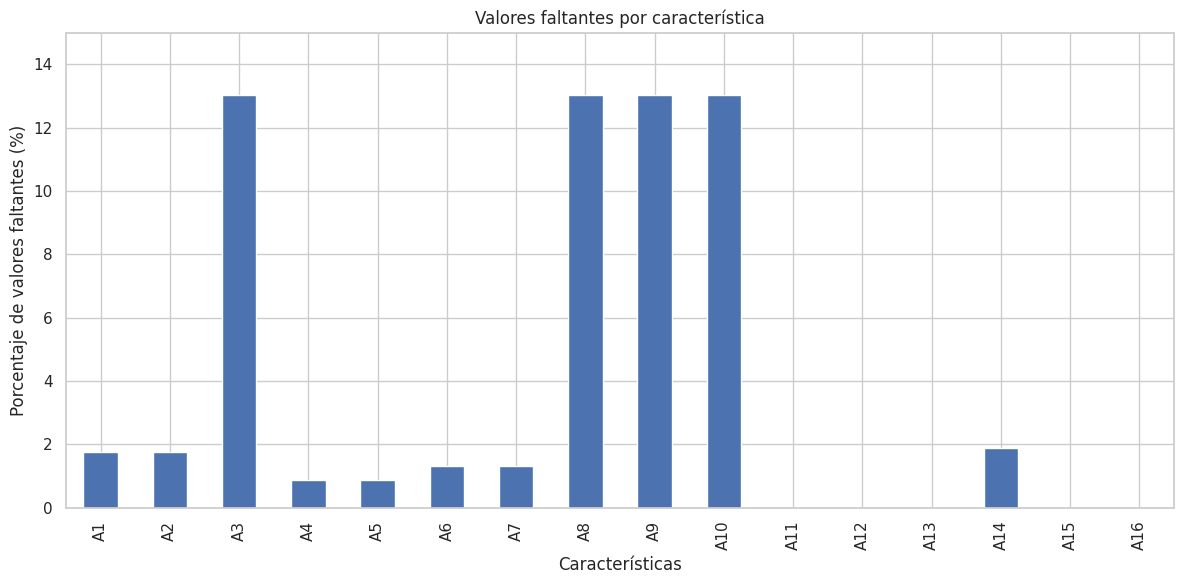

In [14]:
missing_percent_plot = data.isnull().mean().mul(100)

ax = missing_percent_plot.plot.bar(figsize=(12, 6))
ax.set_ylabel("Porcentaje de valores faltantes (%)")
ax.set_xlabel("Características")
ax.set_title("Valores faltantes por característica")
ax.set_ylim(0, max(1, missing_percent_plot.max() * 1.15))

plt.tight_layout()
plt.show()


## 8. Eliminación de observaciones con valores faltantes

La opción más rápida es eliminar todas las observaciones que tengan algún valor faltante.

Ventaja: es un método simple y preserva la distribución de las variables restantes.

Desventaja: puede eliminar una parte importante del dataset y provocar pérdida de información.

In [15]:
data_cca = data.dropna()

print(f"Número total de observaciones: {len(data)}")
print(f"Número total de observaciones sin valores faltantes: {len(data_cca)}")
print(f"Observaciones eliminadas: {len(data) - len(data_cca)}")
print(f"Porcentaje eliminado: {round((1 - len(data_cca) / len(data)) * 100, 2)}%")

Número total de observaciones: 690
Número total de observaciones sin valores faltantes: 565
Observaciones eliminadas: 125
Porcentaje eliminado: 18.12%


## 9. ¿Cuál es el mejor método de imputación?

No hay un método correcto para todos los casos.

La elección depende de:

- Si los valores faltantes aparecen al azar o siguen algún patrón.
- El número y porcentaje de datos ausentes.
- El tipo de variable: numérica o categórica.
- El modelo de Machine Learning que se quiera entrenar después.
- Si la ausencia de información puede ser informativa.

A partir de aquí aplicaremos distintas técnicas usando tanto `pandas` como `scikit-learn`.

## 10. División en entrenamiento y prueba

Cuando vamos a preparar datos para Machine Learning, los valores utilizados para imputar deben calcularse solo con el conjunto de entrenamiento.

Esto evita fuga de información desde el conjunto de prueba hacia el entrenamiento.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop("A16", axis=1),
    data["A16"],
    test_size=0.3,
    random_state=0
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (483, 15)
X_test: (207, 15)
y_train: (483,)
y_test: (207,)


## 11. Identificar variables numéricas y categóricas

La media y la mediana se aplican normalmente a variables numéricas.

La moda o categoría más frecuente se aplica normalmente a variables categóricas.

In [17]:
cols_numericas = [carac for carac in X_train.columns if X_train[carac].dtype != "object"]
cols_categoricas = [carac for carac in X_train.columns if X_train[carac].dtype == "object"]

print("Columnas numéricas:")
print(cols_numericas)

print("\nColumnas categóricas:")
print(cols_categoricas)

Columnas numéricas:
['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

Columnas categóricas:
['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


## 12. Imputación con media o mediana

Este método consiste en reemplazar los valores faltantes de una variable numérica por la media o la mediana de esa variable.

Como regla práctica:

- Usa la media si la variable tiene una distribución aproximadamente normal.
- Usa la mediana si la variable tiene una distribución asimétrica o valores extremos.

En este ejemplo utilizaremos la mediana porque suele ser más robusta.

### 12.1. Imputación con mediana usando Pandas

Calculamos la mediana en `X_train` y usamos ese mismo valor para imputar tanto `X_train` como `X_test`.

In [18]:
X_train_pandas_median = X_train.copy()
X_test_pandas_median = X_test.copy()

for carac in cols_numericas:
    valor = X_train_pandas_median[carac].median()
    X_train_pandas_median[carac] = X_train_pandas_median[carac].fillna(valor)
    X_test_pandas_median[carac] = X_test_pandas_median[carac].fillna(valor)

X_train_pandas_median.isnull().sum()

,0
A1,4
A2,0
A3,0
A4,4
A5,4
A6,4
A7,4
A8,0
A9,72
A10,72


### 12.2. Imputación con mediana usando Scikit-learn

Con `SimpleImputer(strategy="median")`, `scikit-learn` aprende las medianas en el conjunto de entrenamiento y después transforma entrenamiento y prueba con esos mismos valores.

In [19]:
X_train_sklearn_median = X_train.copy()
X_test_sklearn_median = X_test.copy()

imputer_median = SimpleImputer(strategy="median")

imputer_median.fit(X_train_sklearn_median[cols_numericas])

imputer_median.statistics_

array([ 28.835,   3.   ,   1.085,   0.   , 160.   ,   6.   ])

In [20]:
X_train_sklearn_median[cols_numericas] = imputer_median.transform(X_train_sklearn_median[cols_numericas])
X_test_sklearn_median[cols_numericas] = imputer_median.transform(X_test_sklearn_median[cols_numericas])

X_train_sklearn_median.isnull().sum()

,0
A1,4
A2,0
A3,0
A4,4
A5,4
A6,4
A7,4
A8,0
A9,72
A10,72


## 13. Imputación con moda o categoría más frecuente

Esta técnica sustituye los valores faltantes por la categoría que aparece con mayor frecuencia.

Se usa principalmente en variables categóricas.

### 13.1. Imputación con moda usando Pandas

In [21]:
X_train_pandas_mode = X_train.copy()
X_test_pandas_mode = X_test.copy()

for carac in cols_categoricas:
    valor = X_train_pandas_mode[carac].mode()[0]
    X_train_pandas_mode[carac] = X_train_pandas_mode[carac].fillna(valor)
    X_test_pandas_mode[carac] = X_test_pandas_mode[carac].fillna(valor)

X_train_pandas_mode.isnull().sum()

,0
A1,0
A2,11
A3,72
A4,0
A5,0
A6,0
A7,0
A8,72
A9,0
A10,0


### 13.2. Imputación con moda usando Scikit-learn

In [22]:
X_train_sklearn_mode = X_train.copy()
X_test_sklearn_mode = X_test.copy()

imputer_mode = SimpleImputer(strategy="most_frequent")

imputer_mode.fit(X_train_sklearn_mode[cols_categoricas])

imputer_mode.statistics_

array(['b', 'u', 'g', 'c', 'v', 't', 'f', 'f', 'g'], dtype=object)

In [23]:
X_train_sklearn_mode[cols_categoricas] = imputer_mode.transform(X_train_sklearn_mode[cols_categoricas])
X_test_sklearn_mode[cols_categoricas] = imputer_mode.transform(X_test_sklearn_mode[cols_categoricas])

X_train_sklearn_mode.isnull().sum()

,0
A1,0
A2,11
A3,72
A4,0
A5,0
A6,0
A7,0
A8,72
A9,0
A10,0


## 14. Imputación con una observación aleatoria

Esta técnica consiste en reemplazar cada valor faltante por un valor observado aleatorio de la misma variable.

Puede preservar mejor la distribución original que imputar siempre la media o la mediana, aunque introduce aleatoriedad.

### 14.1. Ejemplo con una sola variable: `A2`

Primero contamos cuántos valores faltan en `A2`.

In [24]:
X_train_random_example = X_train.copy()

numero_na = X_train_random_example["A2"].isnull().sum()
numero_na

np.int64(11)

Extraemos del conjunto de entrenamiento tantos valores aleatorios como valores faltantes existan en la variable.

In [25]:
muestra_aleatoria = X_train_random_example["A2"].dropna().sample(numero_na, random_state=0)

muestra_aleatoria

,A2
331,33.25
293,35.75
316,21.17
25,15.83
320,21.25
577,25.17
356,41.17
53,34.92
361,23.08
419,26.58


Para reemplazar valores en una Serie de pandas con otra, los índices deben coincidir. Por eso reindexamos la muestra aleatoria con los índices de las observaciones donde `A2` es nulo.

In [26]:
muestra_aleatoria.index = X_train_random_example[X_train_random_example["A2"].isnull()].index

muestra_aleatoria

,A2
97,33.25
500,35.75
329,21.17
83,15.83
254,21.25
608,25.17
445,41.17
450,34.92
515,23.08
286,26.58


In [27]:
X_train_random_example.loc[X_train_random_example["A2"].isnull(), "A2"] = muestra_aleatoria

X_train_random_example["A2"].isnull().sum()

np.int64(0)

### 14.2. Imputación aleatoria en todas las variables numéricas

Aplicamos la misma lógica a todas las variables numéricas con valores faltantes.

In [28]:
X_train_random = X_train.copy()
X_test_random = X_test.copy()

rng = np.random.default_rng(0)

for carac in cols_numericas:
    valores_disponibles = X_train[carac].dropna().to_numpy()

    if len(valores_disponibles) == 0:
        raise ValueError(
            f"La columna {carac} no contiene valores observados en entrenamiento."
        )

    mask_train = X_train_random[carac].isna()
    if mask_train.any():
        X_train_random.loc[mask_train, carac] = rng.choice(
            valores_disponibles,
            size=mask_train.sum(),
            replace=True
        )

    mask_test = X_test_random[carac].isna()
    if mask_test.any():
        X_test_random.loc[mask_test, carac] = rng.choice(
            valores_disponibles,
            size=mask_test.sum(),
            replace=True
        )

print("Valores faltantes numéricos en train:")
print(X_train_random[cols_numericas].isna().sum())

print("\nValores faltantes numéricos en test:")
print(X_test_random[cols_numericas].isna().sum())


Valores faltantes numéricos en train:
A2     0
A3     0
A8     0
A11    0
A14    0
A15    0
dtype: int64

Valores faltantes numéricos en test:
A2     0
A3     0
A8     0
A11    0
A14    0
A15    0
dtype: int64


## 15. Reemplazar valores faltantes con un número arbitrario

Este método sustituye los valores faltantes por un número situado fuera del rango observado de cada variable.

Debe emplearse con precaución: un valor excesivamente grande puede distorsionar medias, desviaciones, escalados, distancias y modelos lineales. Por ello, en el ejemplo con Pandas se calcula un valor distinto para cada columna usando únicamente el conjunto de entrenamiento.

Cuando la ausencia pueda contener información, conviene combinar esta técnica con un indicador de valor faltante.


### 15.1. Imputación con número arbitrario usando Pandas

In [29]:
X_train_arbitrary = X_train.copy()
X_test_arbitrary = X_test.copy()

X_train_arbitrary[cols_numericas].max()

,0
A2,76.750
A3,26.335
A8,20.000
A11,67.000
A14,2000.000
A15,51100.000


In [30]:
valores_arbitrarios = {}

for carac in cols_numericas:
    serie_train = X_train_arbitrary[carac].dropna()

    if serie_train.empty:
        raise ValueError(
            f"No se puede calcular un valor arbitrario para {carac}: "
            "no hay valores observados en entrenamiento."
        )

    minimo = serie_train.min()
    maximo = serie_train.max()
    rango = maximo - minimo

    # Si la columna fuera constante, usamos una unidad por debajo del mínimo.
    valor_arbitrario = minimo - rango if rango > 0 else minimo - 1
    valores_arbitrarios[carac] = valor_arbitrario

    X_train_arbitrary[carac] = X_train_arbitrary[carac].fillna(valor_arbitrario)
    X_test_arbitrary[carac] = X_test_arbitrary[carac].fillna(valor_arbitrario)

print("Valores arbitrarios calculados con X_train:")
print(pd.Series(valores_arbitrarios, name="valor_arbitrario"))

print("\nValores faltantes restantes por columna:")
print(X_train_arbitrary.isna().sum())


Valores arbitrarios calculados con X_train:
A2       -49.250
A3       -26.335
A8       -20.000
A11      -67.000
A14    -2000.000
A15   -51100.000
Name: valor_arbitrario, dtype: float64

Valores faltantes restantes por columna:
A1      4
A2      0
A3      0
A4      4
A5      4
A6      4
A7      4
A8      0
A9     72
A10    72
A11     0
A12     0
A13     0
A14     0
A15     0
dtype: int64


### 15.2. Imputación con número arbitrario usando Scikit-learn

In [31]:
X_train_sklearn_arbitrary = X_train.copy()
X_test_sklearn_arbitrary = X_test.copy()

imputer_arbitrary = SimpleImputer(strategy="constant", fill_value=99999)

imputer_arbitrary.fit(X_train_sklearn_arbitrary[cols_numericas])

X_train_sklearn_arbitrary[cols_numericas] = imputer_arbitrary.transform(X_train_sklearn_arbitrary[cols_numericas])
X_test_sklearn_arbitrary[cols_numericas] = imputer_arbitrary.transform(X_test_sklearn_arbitrary[cols_numericas])

X_train_sklearn_arbitrary.isnull().sum()

,0
A1,4
A2,0
A3,0
A4,4
A5,4
A6,4
A7,4
A8,0
A9,72
A10,72


## 16. Reemplazar valores faltantes por valores al final de la distribución

Esta técnica es parecida a usar un número arbitrario, pero el valor se calcula a partir de la propia distribución de la variable.

Por ejemplo:

- Media + 3 desviaciones típicas.
- Percentil 99.
- Un valor relacionado con el máximo observado.

Aquí usaremos media + 3 desviaciones típicas.

In [32]:
X_train_tail = X_train.copy()
X_test_tail = X_test.copy()

for carac in cols_numericas:
    if X_train_tail[carac].isnull().sum() > 0:
        valor_extremo = X_train_tail[carac].mean() + 3 * X_train_tail[carac].std()
        X_train_tail[carac] = X_train_tail[carac].fillna(valor_extremo)
        X_test_tail[carac] = X_test_tail[carac].fillna(valor_extremo)
        print(f"{carac}: valor extremo usado = {valor_extremo:.2f}")

X_train_tail[cols_numericas].isnull().sum()

A2: valor extremo usado = 68.36
A3: valor extremo usado = 19.88
A8: valor extremo usado = 12.37
A14: valor extremo usado = 710.63


,0
A2,0
A3,0
A8,0
A11,0
A14,0
A15,0


## 17. Capturar información en los valores faltantes

A veces la ausencia de información puede contener una señal útil.

Por ejemplo, que un dato no esté disponible puede deberse a un patrón administrativo, una característica del cliente o una decisión del proceso de recogida de datos.

Podemos capturar esa información de dos formas:

- Crear una categoría adicional llamada `Missing` en variables categóricas.
- Crear una variable indicadora que marque si el dato estaba ausente.

### 17.1. Crear categoría `Missing` en variables categóricas usando Pandas

In [33]:
X_train_cat_missing = X_train.copy()
X_test_cat_missing = X_test.copy()

for carac in cols_categoricas:
    X_train_cat_missing[carac] = X_train_cat_missing[carac].fillna("Missing")
    X_test_cat_missing[carac] = X_test_cat_missing[carac].fillna("Missing")

X_train_cat_missing.isnull().sum()

,0
A1,0
A2,11
A3,72
A4,0
A5,0
A6,0
A7,0
A8,72
A9,0
A10,0


### 17.2. Crear categoría `Missing` usando Scikit-learn

In [34]:
X_train_sklearn_cat_missing = X_train.copy()
X_test_sklearn_cat_missing = X_test.copy()

imputer_cat_missing = SimpleImputer(strategy="constant", fill_value="Missing")

imputer_cat_missing.fit(X_train_sklearn_cat_missing[cols_categoricas])

X_train_sklearn_cat_missing[cols_categoricas] = imputer_cat_missing.transform(X_train_sklearn_cat_missing[cols_categoricas])
X_test_sklearn_cat_missing[cols_categoricas] = imputer_cat_missing.transform(X_test_sklearn_cat_missing[cols_categoricas])

X_train_sklearn_cat_missing.isnull().sum()

,0
A1,0
A2,11
A3,72
A4,0
A5,0
A6,0
A7,0
A8,72
A9,0
A10,0


## 18. Crear indicadores de valores faltantes con NumPy

Otra manera de capturar información es crear una nueva columna binaria que indique si el valor original estaba ausente.

- `1`: el valor faltaba.
- `0`: el valor estaba presente.

In [35]:
X_train_indicator_np = X_train.copy()
X_test_indicator_np = X_test.copy()

cols_con_na = [carac for carac in X_train.columns if X_train[carac].isnull().sum() > 0]

for carac in cols_con_na:
    X_train_indicator_np[carac + "_NA"] = np.where(X_train_indicator_np[carac].isnull(), 1, 0)
    X_test_indicator_np[carac + "_NA"] = np.where(X_test_indicator_np[carac].isnull(), 1, 0)

X_train_indicator_np.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A1_NA,A2_NA,A3_NA,A4_NA,A5_NA,A6_NA,A7_NA,A8_NA,A9_NA,A10_NA,A14_NA
596,a,46.08,3.000,u,g,c,v,2.375,t,t,8,t,g,396.0,4159,0,0,0,0,0,0,0,0,0,0,0
303,a,15.92,2.875,u,g,q,v,0.085,f,f,0,f,g,120.0,0,0,0,0,0,0,0,0,0,0,0,0
204,b,36.33,2.125,y,p,w,v,0.085,t,t,1,f,g,50.0,1187,0,0,0,0,0,0,0,0,0,0,0
351,b,22.17,0.585,y,p,ff,ff,0.000,f,f,0,f,g,100.0,0,0,0,0,0,0,0,0,0,0,0,0
118,b,57.83,7.040,u,g,m,v,14.000,t,t,6,t,g,360.0,1332,0,0,0,0,0,0,0,0,0,0,0


## 19. Crear indicadores con Scikit-learn: `MissingIndicator`

`MissingIndicator` permite crear columnas indicadoras para las variables que tienen valores faltantes.

Con `features="missing-only"` solo se crean indicadores para las características donde hay datos ausentes.

In [36]:
X_train_indicator_sklearn = X_train.copy()
X_test_indicator_sklearn = X_test.copy()

indicator = MissingIndicator(features="missing-only")

indicator.fit(X_train_indicator_sklearn)

indicator.features_

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 13])

In [37]:
indicator_cols = [c + "_NA" for c in X_train_indicator_sklearn.columns[indicator.features_]]

indicator_cols

['A1_NA',
 'A2_NA',
 'A3_NA',
 'A4_NA',
 'A5_NA',
 'A6_NA',
 'A7_NA',
 'A8_NA',
 'A9_NA',
 'A10_NA',
 'A14_NA']

In [38]:
X_train_indicators_df = pd.DataFrame(
    indicator.transform(X_train_indicator_sklearn),
    columns=indicator_cols,
    index=X_train_indicator_sklearn.index
)

X_test_indicators_df = pd.DataFrame(
    indicator.transform(X_test_indicator_sklearn),
    columns=indicator_cols,
    index=X_test_indicator_sklearn.index
)

X_train_indicator_sklearn = pd.concat([X_train_indicator_sklearn, X_train_indicators_df], axis=1)
X_test_indicator_sklearn = pd.concat([X_test_indicator_sklearn, X_test_indicators_df], axis=1)

X_train_indicator_sklearn.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A1_NA,A2_NA,A3_NA,A4_NA,A5_NA,A6_NA,A7_NA,A8_NA,A9_NA,A10_NA,A14_NA
596,a,46.08,3.000,u,g,c,v,2.375,t,t,8,t,g,396.0,4159,False,False,False,False,False,False,False,False,False,False,False
303,a,15.92,2.875,u,g,q,v,0.085,f,f,0,f,g,120.0,0,False,False,False,False,False,False,False,False,False,False,False
204,b,36.33,2.125,y,p,w,v,0.085,t,t,1,f,g,50.0,1187,False,False,False,False,False,False,False,False,False,False,False
351,b,22.17,0.585,y,p,ff,ff,0.000,f,f,0,f,g,100.0,0,False,False,False,False,False,False,False,False,False,False,False
118,b,57.83,7.040,u,g,m,v,14.000,t,t,6,t,g,360.0,1332,False,False,False,False,False,False,False,False,False,False,False


## 20. Tratamiento de valores faltantes con `scikit-learn`

Hasta ahora hemos aplicado técnicas por separado.

En un proyecto real, es habitual tener variables numéricas y categóricas mezcladas. Por eso resulta útil crear una canalización que aplique distintas estrategias de imputación a distintos grupos de variables.

Usaremos:

- `Pipeline`
- `SimpleImputer`
- `ColumnTransformer`

### 20.1. Crear grupos de variables por estrategia

Siguiendo el ejemplo del tutorial:

- `A3` y `A8`: imputación numérica con valor arbitrario.
- `A2` y `A14`: imputación numérica con mediana.
- `A4`, `A5`, `A6`, `A7`: imputación categórica con categoría más frecuente.
- `A1`, `A9`, `A10`: imputación categórica con `Missing`.

Solo usaremos las columnas que realmente existan en el dataset.

In [39]:
X_train_pipeline, X_test_pipeline, y_train_pipeline, y_test_pipeline = train_test_split(
    data.drop("A16", axis=1),
    data["A16"],
    test_size=0.3,
    random_state=0
)

carac_num_arbitrario = [c for c in ["A3", "A8"] if c in X_train_pipeline.columns]
carac_mediana = [c for c in ["A2", "A14"] if c in X_train_pipeline.columns]
carac_cat_frecuente = [c for c in ["A4", "A5", "A6", "A7"] if c in X_train_pipeline.columns]
carac_cat_missing = [c for c in ["A1", "A9", "A10"] if c in X_train_pipeline.columns]

columnas_imputadas = (
    carac_num_arbitrario
    + carac_mediana
    + carac_cat_frecuente
    + carac_cat_missing
)

columnas_con_na_train = X_train_pipeline.columns[
    X_train_pipeline.isna().any()
].tolist()

columnas_sin_estrategia = sorted(
    set(columnas_con_na_train) - set(columnas_imputadas)
)

print("Numéricas con valor arbitrario:", carac_num_arbitrario)
print("Numéricas con mediana:", carac_mediana)
print("Categóricas con moda:", carac_cat_frecuente)
print("Categóricas con Missing:", carac_cat_missing)
print("Columnas con NA sin estrategia:", columnas_sin_estrategia)

if columnas_sin_estrategia:
    raise ValueError(
        "Hay columnas con valores faltantes sin una estrategia de imputación: "
        f"{columnas_sin_estrategia}"
    )


Numéricas con valor arbitrario: ['A3', 'A8']
Numéricas con mediana: ['A2', 'A14']
Categóricas con moda: ['A4', 'A5', 'A6', 'A7']
Categóricas con Missing: ['A1', 'A9', 'A10']
Columnas con NA sin estrategia: []


### 20.2. Crear pipelines de imputación

Creamos cuatro pipelines, cada uno con una estrategia de imputación distinta.

In [40]:
imputer_num_arbitrario = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=-999))
    ]
)

imputer_mediana = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

imputer_cat_frecuente = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

imputer_cat_missing = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing"))
    ]
)


### 20.3. Crear `ColumnTransformer`

`ColumnTransformer` permite aplicar cada pipeline a un subconjunto distinto de columnas.

El parámetro `remainder="passthrough"` conserva el resto de columnas sin transformarlas.

In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        ("imp_num_arbitrario", imputer_num_arbitrario, carac_num_arbitrario),
        ("imp_mediana", imputer_mediana, carac_mediana),
        ("imp_cat_frecuente", imputer_cat_frecuente, carac_cat_frecuente),
        ("imp_cat_missing", imputer_cat_missing, carac_cat_missing),
    ],
    remainder="passthrough"
)

preprocessor.fit(X_train_pipeline)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imp_num_arbitrario',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=-999,
                                                                strategy='constant'))]),
                                 ['A3', 'A8']),
                                ('imp_mediana',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['A2', 'A14']),
                                ('imp_cat_frecuente',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['A4', 'A5', 'A6', 'A7']),
                                ('imp_cat_missing',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Missing',
                                                                strategy='constant'))]),
                                 ['A1', 'A9', 'A10'])])

### 20.4. Transformar entrenamiento y prueba

Aplicamos el `preprocessor` a `X_train` y `X_test`.

Después reconstruimos el resultado como `DataFrame` para conservar el índice y los nombres de las columnas. Finalmente, comprobamos que la transformación no deja valores faltantes.


In [42]:
X_train_array = preprocessor.transform(X_train_pipeline)
X_test_array = preprocessor.transform(X_test_pipeline)

columnas_salida = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_array,
    columns=columnas_salida,
    index=X_train_pipeline.index
)

X_test_processed = pd.DataFrame(
    X_test_array,
    columns=columnas_salida,
    index=X_test_pipeline.index
)

na_train_processed = X_train_processed.isna().sum().sum()
na_test_processed = X_test_processed.isna().sum().sum()

print("X_train procesado:", X_train_processed.shape)
print("X_test procesado:", X_test_processed.shape)
print("Valores faltantes en train procesado:", na_train_processed)
print("Valores faltantes en test procesado:", na_test_processed)

assert na_train_processed == 0, "Quedan valores faltantes en X_train_processed."
assert na_test_processed == 0, "Quedan valores faltantes en X_test_processed."

X_train_processed.head()


X_train procesado: (483, 15)
X_test procesado: (207, 15)
Valores faltantes en train procesado: 0
Valores faltantes en test procesado: 0


,imp_num_arbitrario__A3,imp_num_arbitrario__A8,imp_mediana__A2,imp_mediana__A14,imp_cat_frecuente__A4,imp_cat_frecuente__A5,imp_cat_frecuente__A6,imp_cat_frecuente__A7,imp_cat_missing__A1,imp_cat_missing__A9,imp_cat_missing__A10,remainder__A11,remainder__A12,remainder__A13,remainder__A15
596,3.0,2.375,46.08,396.0,u,g,c,v,a,t,t,8,t,g,4159
303,2.875,0.085,15.92,120.0,u,g,q,v,a,f,f,0,f,g,0
204,2.125,0.085,36.33,50.0,y,p,w,v,b,t,t,1,f,g,1187
351,0.585,0.0,22.17,100.0,y,p,ff,ff,b,f,f,0,f,g,0
118,7.04,14.0,57.83,360.0,u,g,m,v,b,t,t,6,t,g,1332


## 21. Comparación de estrategias

Cada método mostrado en las secciones anteriores trata solo un tipo de variable. Por tanto, la comparación se realiza sobre las columnas a las que se aplicó cada estrategia, evitando interpretar como fallo los valores ausentes de columnas que ese método no pretendía modificar.


In [43]:
comparison = pd.DataFrame({
    "original_numeric": [
        X_train[cols_numericas].isna().sum().sum()
    ],
    "median_numeric": [
        X_train_pandas_median[cols_numericas].isna().sum().sum()
    ],
    "random_numeric": [
        X_train_random[cols_numericas].isna().sum().sum()
    ],
    "arbitrary_numeric": [
        X_train_arbitrary[cols_numericas].isna().sum().sum()
    ],
    "tail_numeric": [
        X_train_tail[cols_numericas].isna().sum().sum()
    ],
    "original_categorical": [
        X_train[cols_categoricas].isna().sum().sum()
    ],
    "mode_categorical": [
        X_train_pandas_mode[cols_categoricas].isna().sum().sum()
    ],
    "missing_category": [
        X_train_cat_missing[cols_categoricas].isna().sum().sum()
    ],
    "complete_pipeline": [
        X_train_processed.isna().sum().sum()
    ]
}).T

comparison.columns = ["remaining_missing_values"]
comparison


,remaining_missing_values
original_numeric,162
median_numeric,0
random_numeric,0
arbitrary_numeric,0
tail_numeric,0
original_categorical,164
mode_categorical,0
missing_category,0
complete_pipeline,0


## 22. Conclusiones

El tratamiento de valores faltantes es una fase esencial del análisis de datos y del Machine Learning.

En este notebook hemos visto que existen varias estrategias:

- Eliminar observaciones incompletas.
- Imputar variables numéricas con media o mediana.
- Imputar variables categóricas con moda.
- Imputar con valores aleatorios observados.
- Sustituir valores ausentes por números arbitrarios.
- Sustituir valores ausentes por valores extremos.
- Crear categorías `Missing`.
- Crear indicadores de ausencia.
- Usar `MissingIndicator`.
- Crear una canalización con `Pipeline` y `ColumnTransformer`.

No hay una técnica universalmente mejor. La decisión debe depender del tipo de variable, del porcentaje de valores faltantes, del patrón de ausencia y del objetivo final del análisis o del modelo.